In [1]:
# importing libraries
from pathlib import Path
import gc
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from transformers import AutoConfig, pipeline

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
MAX_LENGTH = 256

In [3]:
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 0 if torch.cuda.is_available() else -1

In [4]:
validation_folder = Path("../../data/processed/canceremo/validation")
testing_folder = Path("../../data/processed/canceremo/testing")

In [5]:
output_folder = Path("outputs/text")
output_folder.mkdir(parents=True, exist_ok=True)

In [6]:
# Emotions supported by all six models
emotions = ["anger", "fear", "joy", "sadness", "surprise"]

In [7]:
# Candidate text models
models = {
    "DistilBERT": {
        "model_id": ("bhadresh-savani/distilbert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 32
    },

    "BERT": {
        "model_id": ("bhadresh-savani/bert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    "RoBERTa": {
        "model_id": ("bhadresh-savani/roberta-base-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    "DistilRoBERTa": {
        "model_id": ("j-hartmann/emotion-english-distilroberta-base"),
        "training_data": "Six external emotion datasets",
        "batch_size": 16
    },

    "BERT-Nateraw": {
        "model_id": ("nateraw/bert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    "RoBERTa-Large": {
        "model_id": ("j-hartmann/emotion-english-roberta-large"),
        "training_data": "Six external emotion datasets",
        "batch_size": 4
    }
}

In [8]:
print("Models:", len(models))
print("Emotions:", emotions)

Models: 6
Emotions: ['anger', 'fear', 'joy', 'sadness', 'surprise']


In [9]:
model_information = []

In [10]:
for model_name, details in models.items():
    model_information.append({
        "Model": model_name,
        "Model ID": details["model_id"],
        "Training Data": details["training_data"],
        "CancerEmo Overlap": "No"
    })

In [11]:
model_information_df = pd.DataFrame(model_information)
model_information_df

,Model,Model ID,Training Data,CancerEmo Overlap
0,DistilBERT,bhadresh-savani/distilbert-base-uncased-emotion,dair-ai/emotion,No
1,BERT,bhadresh-savani/bert-base-uncased-emotion,dair-ai/emotion,No
2,RoBERTa,bhadresh-savani/roberta-base-emotion,dair-ai/emotion,No
3,DistilRoBERTa,j-hartmann/emotion-english-distilroberta-base,Six external emotion datasets,No
4,BERT-Nateraw,nateraw/bert-base-uncased-emotion,dair-ai/emotion,No
5,RoBERTa-Large,j-hartmann/emotion-english-roberta-large,Six external emotion datasets,No


In [12]:
def load_split(folder):
    split_data = {}

    for emotion in emotions:
        file_path = folder / f"{emotion}.csv"
        data = pd.read_csv(file_path)

        label_column = [
            column
            for column in data.columns
            if column != "Sentence"
        ][0]

        data = data[["Sentence", label_column]].copy()
        data.columns = ["text", "label"]
        data["text"] = (data["text"].fillna("").astype(str).str.strip())
        data["label"] = data["label"].astype(int)
        split_data[emotion] = data

    return split_data

In [13]:
validation_data = load_split(validation_folder)
testing_data = load_split(testing_folder)

In [14]:
record_counts = []

In [15]:
for emotion in emotions:
    record_counts.append({
        "Emotion": emotion,
        "Validation": len(validation_data[emotion]),
        "Testing": len(testing_data[emotion])
    })

In [16]:
pd.DataFrame(record_counts)

,Emotion,Validation,Testing
0,anger,84,84
1,fear,539,539
2,joy,604,605
3,sadness,361,361
4,surprise,102,110


In [17]:
# Handle small differences between model labels
label_aliases = {
    "angry": "anger",
    "happy": "joy",
    "sad": "sadness",
    "surprised": "surprise"
}

In [18]:
def clean_label(label):
    label = str(label).strip().lower()
    return label_aliases.get(label, label)

In [19]:
def get_scores(outputs, emotion):
    scores = []

    for prediction_list in outputs:
        prediction_scores = {
            clean_label(item["label"]): float(item["score"])
            for item in prediction_list
        }

        scores.append(prediction_scores[emotion])

    return np.array(scores)

In [20]:
def find_threshold(y_true, y_scores):
    best_threshold = 0.50
    best_f1 = -1

    for threshold in np.arange(0.05, 1.00, 0.05):
        predictions = (y_scores >= threshold).astype(int)
        current_f1 = f1_score(y_true,predictions, average="macro", zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(threshold)

    return best_threshold

In [21]:
def calculate_metrics(y_true, y_scores, threshold):
    predictions = (y_scores >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "macro_precision": precision_score(y_true, predictions,average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, predictions, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, predictions, average="macro", zero_division=0)
    }

In [22]:
def evaluate_model(model_name,model_details, split_data, split_name, fixed_thresholds=None):
    model_id = model_details["model_id"]
    batch_size = model_details["batch_size"]

    loading_start = time.perf_counter()

    classifier = pipeline("text-classification", model=model_id, tokenizer=model_id, top_k=None, device=device)

    loading_time = (time.perf_counter() - loading_start)
    available_labels = {
        clean_label(label)
        for label
        in classifier.model.config.id2label.values()
    }

    results = []
    thresholds = {}
    predictions_by_emotion = {}

    total_inference_time = 0

    for emotion in emotions:
        data = split_data[emotion]

        texts = data["text"].tolist()
        y_true = data["label"].to_numpy()

        inference_start = time.perf_counter()

        outputs = classifier(texts, batch_size=batch_size, truncation=True, max_length=MAX_LENGTH)
        inference_time = (time.perf_counter() - inference_start)
        total_inference_time += inference_time
        y_scores = get_scores(outputs, emotion)
        if fixed_thresholds is None:
            threshold = find_threshold(y_true, y_scores)
        else:
            threshold = fixed_thresholds[emotion]

        thresholds[emotion] = threshold

        metric_values = calculate_metrics(y_true, y_scores, threshold)

        results.append({
            "model": model_name,
            "split": split_name,
            "emotion": emotion,
            **metric_values,
            "inference_time": inference_time
        })

        predictions_by_emotion[emotion] = {
            "actual": y_true,
            "predicted": (y_scores >= threshold).astype(int)
        }

    return {
        "results": pd.DataFrame(results),
        "thresholds": thresholds,
        "predictions": predictions_by_emotion,
        "loading_time": loading_time,
        "inference_time": total_inference_time
    }

In [23]:
validation_results = []
comparison_results = []
model_thresholds = {}

In [24]:
for model_name, model_details in models.items():
    print(f"\nEvaluating {model_name}...")

    evaluation = evaluate_model(model_name, model_details, validation_data, "validation")
    results = evaluation["results"]

    validation_results.append(results)

    model_thresholds[model_name] = (evaluation["thresholds"])

    comparison_results.append({
        "Model": model_name,
        "Accuracy": (results["accuracy"].mean()),
        "Macro Precision": (results["macro_precision"].mean()),
        "Macro Recall": (results["macro_recall"].mean()),
        "Macro-F1": (results["macro_f1"].mean()),
        "Loading Time": (evaluation["loading_time"]),
        "Inference Time": (evaluation["inference_time"])
    })

    print("Macro-F1:", round(results["macro_f1"].mean(), 4))


Evaluating DistilBERT...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8251.82it/s]


Macro-F1: 0.6192

Evaluating BERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7271.35it/s]


Macro-F1: 0.6249

Evaluating RoBERTa...


...

Macro-F1: 0.709

Evaluating BERT-Nateraw...


Loading weights: 100%|██████████| 201/201 [00:00<?, ?it/s]


Macro-F1: 0.6194

Evaluating RoBERTa-Large...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 56431.41it/s]


Macro-F1: 0.732


In [25]:
validation_results_df = pd.concat(validation_results,ignore_index=True)
comparison_df = pd.DataFrame(comparison_results)

In [26]:
comparison_df = comparison_df.sort_values(["Macro-F1", "Inference Time"], ascending=[False, True]).reset_index(drop=True)
comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time
0,RoBERTa-Large,0.737207,0.750861,0.736161,0.732035,2.606175,9.398584
1,DistilRoBERTa,0.714971,0.726063,0.712365,0.709041,2.097172,2.149314
2,BERT,0.651124,0.670581,0.650376,0.624922,1.773047,3.400131
3,RoBERTa,0.658547,0.721309,0.659115,0.623444,1.981222,3.483005
4,BERT-Nateraw,0.647154,0.680230,0.647301,0.619366,2.063480,3.637666
5,DistilBERT,0.652134,0.709997,0.652752,0.619196,2.420014,2.289711


In [27]:
emotion_results = validation_results_df[
    [
        "model",
        "emotion",
        "threshold",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "inference_time"
    ]
].sort_values(["model", "emotion"])

In [28]:
emotion_results

,model,emotion,threshold,accuracy,macro_precision,macro_recall,macro_f1,inference_time
5,BERT,anger,0.50,0.678571,0.703581,0.674135,0.664844,0.121321
6,BERT,fear,0.10,0.653061,0.664334,0.647588,0.641695,1.154771
7,BERT,joy,0.75,0.728477,0.730395,0.726754,0.726751,1.043578
8,BERT,sadness,0.05,0.675900,0.686777,0.683797,0.675542,0.936389
9,BERT,surprise,0.05,0.519608,0.567819,0.519608,0.415780,0.144072
20,BERT-Nateraw,anger,0.40,0.666667,0.693559,0.661940,0.650624,0.326653
21,BERT-Nateraw,fear,0.05,0.636364,0.636164,0.634471,0.634247,1.194941
22,BERT-Nateraw,joy,0.85,0.713576,0.713321,0.713173,0.713230,1.044322
23,BERT-Nateraw,sadness,0.10,0.689751,0.700373,0.697511,0.689462,0.918789
24,BERT-Nateraw,surprise,0.05,0.529412,0.657732,0.529412,0.409266,0.152961


In [29]:
selected_model_name = comparison_df.loc[0, "Model"]
selected_model_details = models[selected_model_name]
selected_thresholds = model_thresholds[selected_model_name]

print("Selected model:", selected_model_name)
print("Model ID:", selected_model_details["model_id"])

print("\nSelected thresholds:")

for emotion, threshold in selected_thresholds.items():
    print(f"{emotion}: {threshold:.2f}")

Selected model: RoBERTa-Large
Model ID: j-hartmann/emotion-english-roberta-large

Selected thresholds:
anger: 0.05
fear: 0.05
joy: 0.15
sadness: 0.10
surprise: 0.05


In [30]:
test_evaluation = evaluate_model(selected_model_name, selected_model_details, testing_data, "testing", fixed_thresholds=selected_thresholds)
test_results_df = test_evaluation["results"]
test_predictions = test_evaluation["predictions"]

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 19928.45it/s]


In [31]:
display(test_results_df[["emotion", "threshold", "accuracy", "macro_precision", "macro_recall", "macro_f1", "inference_time"]])

,emotion,threshold,accuracy,macro_precision,macro_recall,macro_f1,inference_time
0,anger,0.05,0.821429,0.849964,0.788824,0.800853,0.643993
1,fear,0.05,0.653061,0.668421,0.660535,0.650734,2.999815
2,joy,0.15,0.808264,0.812274,0.807981,0.807545,3.147025
3,sadness,0.10,0.675900,0.677434,0.675767,0.675093,2.050103
4,surprise,0.05,0.690909,0.695035,0.690909,0.689266,0.593683


In [32]:
test_summary_df = pd.DataFrame([
    {
        "Selected Model": selected_model_name,

        "Average Accuracy": (test_results_df["accuracy"].mean()),
        "Average Macro Precision": (test_results_df["macro_precision"].mean()),
        "Average Macro Recall": (test_results_df["macro_recall"].mean()),
        "Average Macro-F1": (test_results_df["macro_f1"].mean()),
        "Loading Time": (test_evaluation["loading_time"]),
        "Inference Time": (test_evaluation["inference_time"])
    }
])

In [33]:
test_summary_df

,Selected Model,Average Accuracy,Average Macro Precision,Average Macro Recall,Average Macro-F1,Loading Time,Inference Time
0,RoBERTa-Large,0.729913,0.740626,0.724803,0.724698,2.589103,9.43462


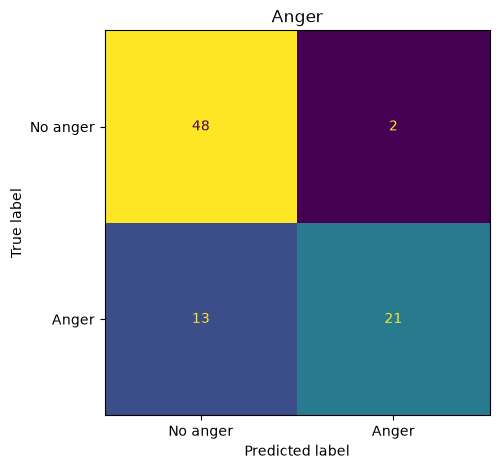

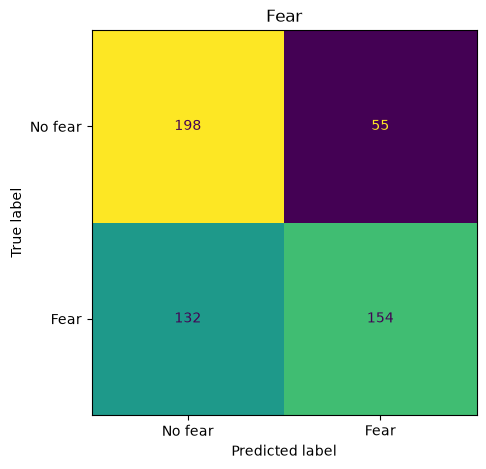

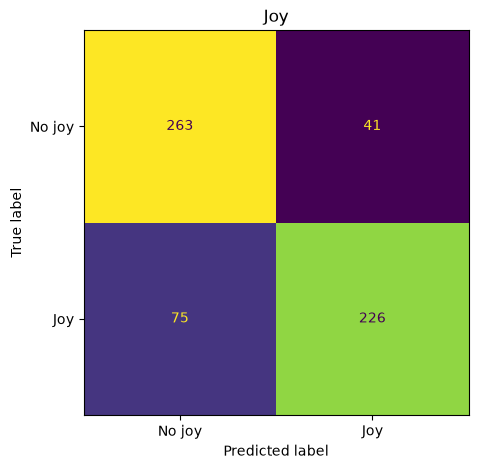

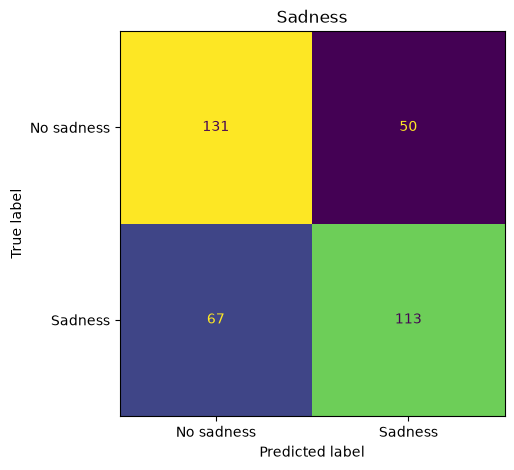

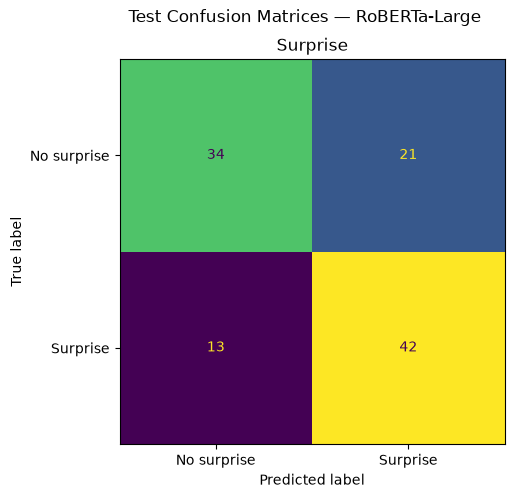

In [34]:
for emotion in emotions:
    values = test_predictions[emotion]
    figure, axis = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(values["actual"], values["predicted"], display_labels=[f"No {emotion}", emotion.capitalize()], ax=axis, colorbar=False)

    axis.set_title(emotion.capitalize())

plt.suptitle(f"Test Confusion Matrices — " f"{selected_model_name}")
plt.savefig(output_folder/ "text_test_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

In [35]:
validation_results_df.to_csv(output_folder/ "validation_results_by_emotion.csv",index=False)
comparison_df.to_csv(output_folder/ "text_model_comparison.csv",index=False)
test_results_df.to_csv(output_folder/ "selected_model_test_results.csv",index=False)
test_summary_df.to_csv(output_folder/ "selected_model_test_summary.csv",index=False)
print("Results saved in:", output_folder)

Results saved in: outputs\text
